# **T01 - Caminata aleatoria**
## **Simulación de Procesos Financieros**

---

**Autor:** Francisco Uriel Ledezma Chávez  
**Carrera:** Ingeniería Financiera  
**Institución:** ITESO — Universidad Jesuita de Guadalajara  
**Semestre:** 5° — Simulación de Procesos Financieros  
**Fecha de realización:** 23 de agosto de 2026

---

En este notebook se simulan una caminata aleatoria en tres dimensiones y una estrategia de apuestas, con el propósito de observar cómo decisiones aleatorias sencillas pueden producir trayectorias muy diferentes.

## Índice de contenidos

1. Sección 1 — Simulación del movimiento browniano
2. Sección 2 — Apuesta arriesgada
3. Sección 3 — Conclusiones

## Importación de bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(23)

## 1. Simulación del movimiento browniano

El movimiento se aproxima mediante una caminata aleatoria independiente para cada eje, donde en cada intervalo la posición aumenta o disminuye la cantidad $\sqrt{\Delta t}$ con la misma probabilidad.

$$W_i = W_{i-1} + X_i\sqrt{\Delta t}, \qquad X_i \in \{-1,1\}$$

### 1.1 Parámetros y simulación

In [2]:
dt = 0.001
tiempo_total = 10
numero_pasos = int(tiempo_total / dt)

x = [0]
y = [0]
z = [0]

for paso in range(numero_pasos):
    salto_x = np.random.choice([-1, 1]) * np.sqrt(dt)
    salto_y = np.random.choice([-1, 1]) * np.sqrt(dt)
    salto_z = np.random.choice([-1, 1]) * np.sqrt(dt)

    x.append(x[-1] + salto_x)
    y.append(y[-1] + salto_y)
    z.append(z[-1] + salto_z)

### 1.2 Trayectoria en tres dimensiones

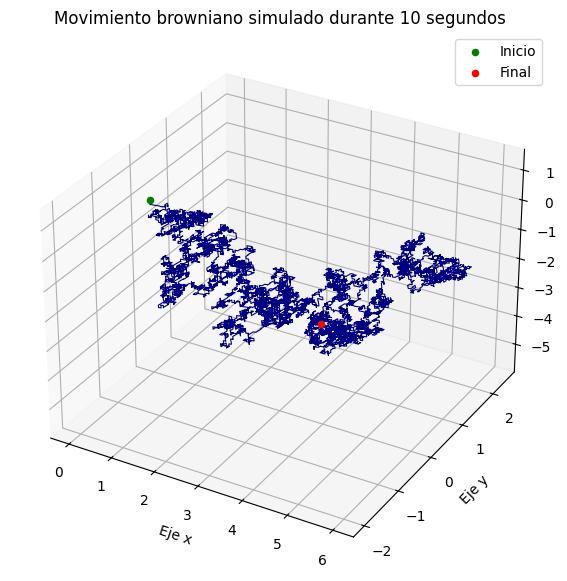

In [3]:
figura = plt.figure(figsize=(9, 7))
grafica = figura.add_subplot(111, projection="3d")

grafica.plot(x, y, z, color="navy", linewidth=0.8)
grafica.scatter(x[0], y[0], z[0], color="green", label="Inicio")
grafica.scatter(x[-1], y[-1], z[-1], color="red", label="Final")

grafica.set_title("Movimiento browniano simulado durante 10 segundos")
grafica.set_xlabel("Eje x")
grafica.set_ylabel("Eje y")
grafica.set_zlabel("Eje z")
grafica.legend()
plt.show()

La trayectoria cambia de dirección en cada paso y no presenta una tendencia fija, ya que los desplazamientos positivos y negativos tienen la misma probabilidad, aunque su acumulación produce una ruta irregular que se aleja temporalmente del origen.

## 2. Apuesta arriesgada

El jugador comienza con 20 pesos y en cada volado gana o pierde la apuesta, la cual equivale a la mitad de su capital cuando dispone de al menos 6 pesos y a 2 pesos cuando se encuentra por debajo de ese nivel.

$$C_{i+1} = C_i + V_iA_i, \qquad A_i = \begin{cases} C_i/2, & C_i \geq 6 \\ 2, & C_i < 6 \end{cases}$$

Si una pérdida lleva el capital por debajo de cero, el evento se considera quiebra y el saldo final se registra en 0 pesos, con ello se conserva la regla de apostar 2 pesos cuando $C_i < 6$ sin representar un capital negativo.

### 2.1 Evolución del capital de un jugador

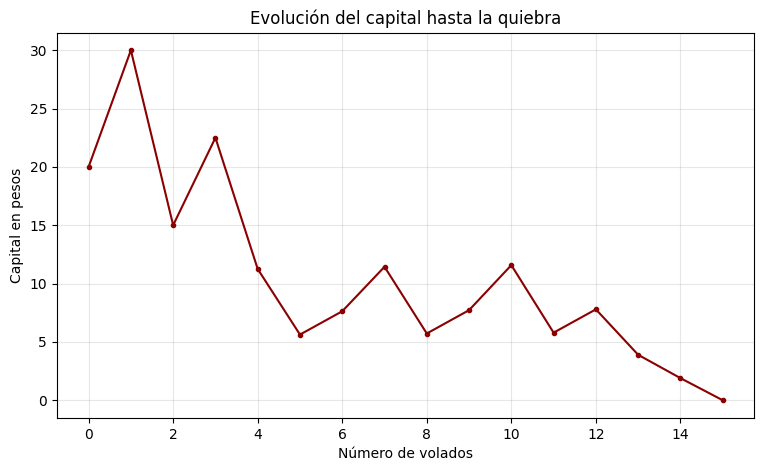

In [4]:
capital_inicial = 20
capital = capital_inicial
historial_capital = [capital]

while capital > 0:
    if capital >= 6:
        apuesta = capital / 2
    else:
        apuesta = 2

    resultado = np.random.choice([-1, 1])
    capital = capital + resultado * apuesta

    # Registrar en cero la quiebra cuando la pérdida cruza el saldo
    if capital < 0:
        capital = 0

    historial_capital.append(capital)

plt.figure(figsize=(9, 5))
plt.plot(historial_capital, marker="o", markersize=3, color="darkred")
plt.title("Evolución del capital hasta la quiebra")
plt.xlabel("Número de volados")
plt.ylabel("Capital en pesos")
plt.grid(alpha=0.3)
plt.show()

Una sola trayectoria permite observar cambios bruscos mientras el capital es alto y variaciones de 2 pesos cerca de la quiebra, pero este recorrido no basta para describir el comportamiento promedio porque depende de una secuencia particular de volados.

### 2.2 Simulación Monte Carlo

Para estimar el tiempo promedio hasta la quiebra se repite el mismo procedimiento con 10,000 jugadores y se guarda el número de volados utilizado en cada recorrido.

In [5]:
numero_jugadores = 10000
volados_quiebra = []

for jugador in range(numero_jugadores):
    capital = capital_inicial
    numero_volados = 0

    while capital > 0:
        if capital >= 6:
            apuesta = capital / 2
        else:
            apuesta = 2

        resultado = np.random.choice([-1, 1])
        capital = capital + resultado * apuesta

        # Registrar en cero la quiebra cuando la pérdida cruza el saldo
        if capital < 0:
            capital = 0

        numero_volados = numero_volados + 1

    volados_quiebra.append(numero_volados)

promedio_volados = np.mean(volados_quiebra)
print(f"Promedio de volados para llegar a la quiebra: {promedio_volados:.2f}")

Promedio de volados para llegar a la quiebra: 26.22


### 2.3 Histograma del número de volados

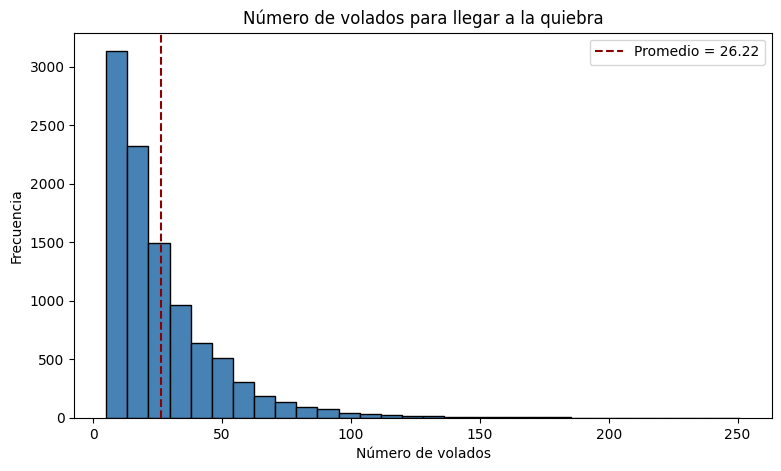

In [6]:
plt.figure(figsize=(9, 5))
plt.hist(volados_quiebra, bins=30, color="steelblue", edgecolor="black")
plt.axvline(promedio_volados, color="darkred", linestyle="--", label=f"Promedio = {promedio_volados:.2f}")
plt.title("Número de volados para llegar a la quiebra")
plt.xlabel("Número de volados")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

El promedio de 26.22 volados resume el tiempo necesario para llegar a la quiebra entre los 10,000 jugadores, aunque la cola hacia la derecha del histograma indica que algunos sobreviven mucho más tiempo y confirma que el promedio no describe por sí solo toda la variación de los recorridos.

## 3. Conclusiones

Las dos simulaciones muestran que reglas sencillas pueden generar resultados irregulares cuando se repiten muchas decisiones aleatorias, mientras la caminata browniana acumula pequeños desplazamientos sin dirección fija, la apuesta produce trayectorias de capital muy distintas y una distribución asimétrica del tiempo hasta la quiebra, por ello una trayectoria individual sirve para ilustrar el proceso, pero la repetición Monte Carlo es necesaria para estimar su comportamiento general.